## Import needed library:
### We need following library:
- pandas
- numpy
- matplotlib
- seaborn

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Define file path to pandas and see some information about our CSV dataframe:

In [30]:
df = pd.read_csv('../data/daily/Binance_BTCUSDT_d.csv')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3101 entries, 0 to 3100
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unix         3101 non-null   int64  
 1   Date         3101 non-null   str    
 2   Symbol       3101 non-null   str    
 3   Open         3101 non-null   float64
 4   High         3101 non-null   float64
 5   Low          3101 non-null   float64
 6   Close        3101 non-null   float64
 7   Volume BTC   3101 non-null   float64
 8   Volume USDT  3101 non-null   float64
 9   tradecount   3101 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 242.4 KB


### Convert Date column from sting to datetype:

In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Unix                    int64
Date           datetime64[us]
Symbol                    str
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume BTC            float64
Volume USDT           float64
tradecount              int64
dtype: object

### See the correlation matrix for numeric columns of dataframe:

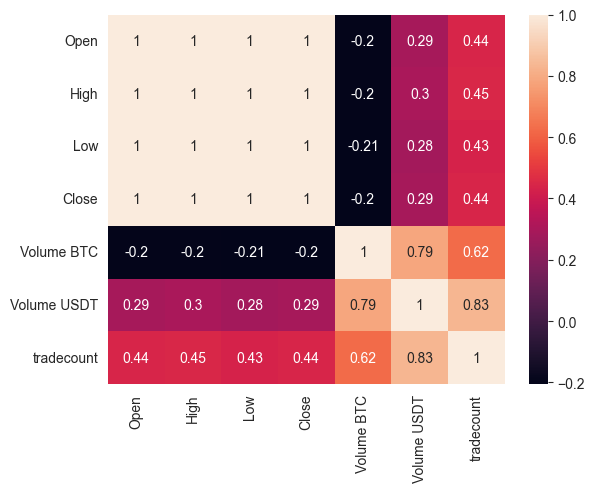

In [32]:
corr = df[['Open', 'High'
,'Low'
, 'Close'
, 'Volume BTC'
, 'Volume USDT'
, 'tradecount']].corr()
sns.heatmap(corr, annot=True)
plt.show()

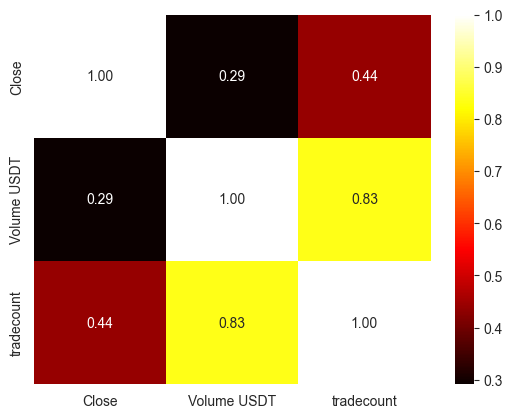

In [33]:
corr2 = df[['Close', 'Volume USDT', 'tradecount']].corr()
sns.heatmap(corr2, annot=True, cmap='hot', fmt='.2f')
plt.show()

### Creating target column:

In [34]:
df['Target'] = df['Close'].shift(1)
df.to_csv('../data/daily/BTCUSDT_d.csv', index=False)
df.head()

,Unix,Date,Symbol,Open,High,Low,Close,Volume BTC,Volume USDT,tradecount,Target
0,1770940800000,2026-02-13,BTCUSDT,66272.17,69482.97,65872.46,68853.96,20244.54955,1.371286e+09,6450842,NaN
1,1770854400000,2026-02-12,BTCUSDT,67082.52,68410.52,65118.00,66272.17,24271.74283,1.622162e+09,6778280,68853.96
2,1770768000000,2026-02-11,BTCUSDT,68841.28,69292.88,65756.00,67082.52,28718.24602,1.930514e+09,6956577,66272.17
3,1770681600000,2026-02-10,BTCUSDT,70138.00,70527.59,67800.00,68841.29,20373.77072,1.408624e+09,4558658,67082.52
4,1770595200000,2026-02-09,BTCUSDT,70330.38,71453.53,68308.00,70138.00,29152.72842,2.038960e+09,6644769,68841.29


In [35]:
new_df = pd.read_csv('../data/daily/BTCUSDT_d.csv')
new_df.isnull().sum()

Unix           0
Date           0
Symbol         0
Open           0
High           0
Low            0
Close          0
Volume BTC     0
Volume USDT    0
tradecount     0
Target         1
dtype: int64

### Removing null row:

In [36]:
new_df.dropna(inplace=True)
new_df.isnull().sum()

Unix           0
Date           0
Symbol         0
Open           0
High           0
Low            0
Close          0
Volume BTC     0
Volume USDT    0
tradecount     0
Target         0
dtype: int64

In [38]:
new_df['Date'] = pd.to_datetime(new_df['Date'])
new_df.dtypes

Unix                    int64
Date           datetime64[us]
Symbol                    str
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume BTC            float64
Volume USDT           float64
tradecount              int64
Target                float64
dtype: object

### Separate data to train RF model:

In [40]:
x = new_df[['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']]
y = new_df['Target']

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=False)

In [43]:
len(x_train), len(x_test), len(y_train), len(y_test)

(2480, 620, 2480, 620)

### Train RFR with separated data:

In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
model.fit(x_train, y_train)

print("RandomForestRegressor were successfully trained.")

RandomForestRegressor were successfully trained.


In [47]:
y_pred = model.predict(x_test)

In [51]:
y_pred

array([ 5450.24641667,  5507.35491667,  5421.56575   ,  5524.53166667,
        5784.92791667,  5785.99708333,  5408.748     ,  5413.64158333,
        5408.11575   ,  5383.89583333,  5347.45675   ,  5332.78891667,
        5355.40608333,  5359.98041667,  5356.99375   ,  5356.40575   ,
        5363.79733333,  5422.65641667,  5371.29458333,  5389.82141667,
        5356.66766667,  5363.25491667,  5359.28941667,  5364.34066667,
        5378.05658333,  5361.91025   ,  5372.214     ,  5355.3355    ,
        5371.06391667,  5363.6905    ,  5379.36416667,  5361.76216667,
        5380.73208333,  5379.36416667,  5381.90666667,  5371.06391667,
        5371.06391667,  5361.76216667,  5382.52041667,  5362.99758333,
        5361.76216667,  5365.86525   ,  5363.6905    ,  5373.71908333,
        5365.86525   ,  5370.72208333,  5363.5175    ,  5357.34583333,
        5382.52041667,  5365.86525   ,  5379.36416667,  5382.52041667,
        5357.34583333,  5366.479     ,  5380.53875   ,  5381.90666667,
      

In [48]:
from sklearn.metrics import mean_absolute_error

mea = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mea)

Mean Absolute Error: 725.3880501344076


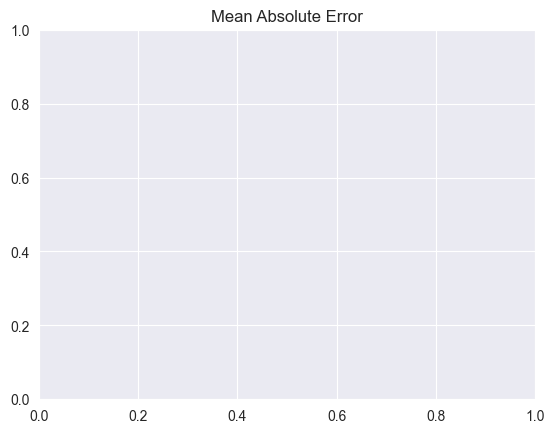

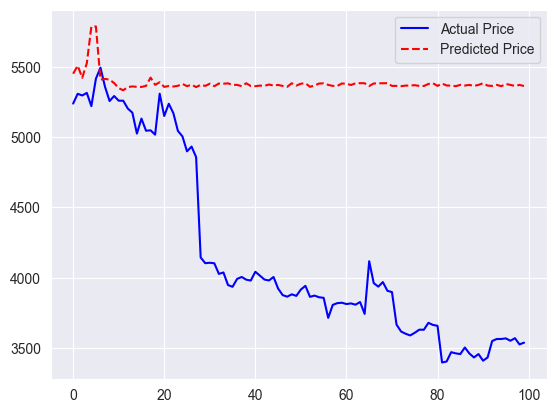

In [49]:
plt.title('Mean Absolute Error')
plt.figure()
plt.plot(y_test.values[:100], label='Actual Price', color='blue')
plt.plot(y_pred[:100], label='Predicted Price', color='red', linestyle='--')
plt.legend()
plt.show()

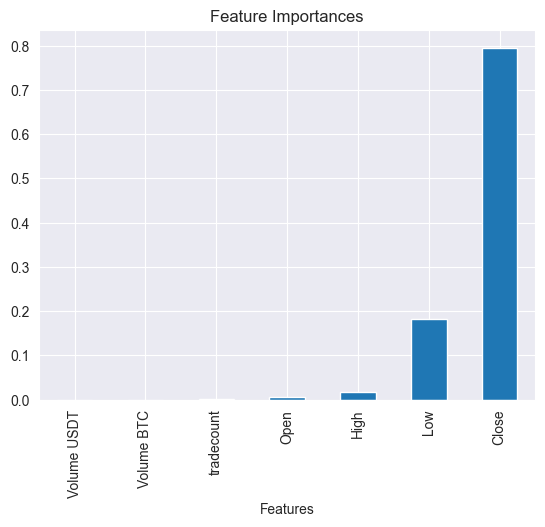

In [57]:
importances = model.feature_importances_
features = ['Open', 'High', 'Low', 'Close', 'Volume BTC', 'Volume USDT', 'tradecount']
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure()
feature_importance_df.plot(kind='bar')
plt.xlabel('Features')
plt.title('Feature Importances')
plt.show()